# Taller 4: Hechos Estilizados Macroeconómicos
**Macroeconomía 2 - Universdiad de los Andes**


---
Replica los hechos estilizados de la economía colombiana, según la metodología de Uribe & Schmitt-Grohé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.filters.hp_filter import hpfilter
import warnings
warnings.filterwarnings('ignore')

# Estética global de gráficos
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

LAMBDA_HP = 1600  # Parámetro std. para datos trimestre.

In [2]:


def cargar_banrep(ruta):
    ws = pd.read_excel(ruta, sheet_name='Series de datos', header=None)
    
    fechas = pd.to_datetime(ws.iloc[1, 1:], dayfirst=True)
    fechas = pd.PeriodIndex(fechas, freq='Q')
    datos = ws.iloc[3:, :]
    datos = datos.set_index(0)
    datos.index.name = None
    datos.columns = fechas
    datos = datos.apply(pd.to_numeric, errors='coerce')
    datos = datos.T

    nombres = datos.columns.tolist()
    datos = datos.rename(columns={
        nombres[0]: 'pib',
        nombres[2]: 'consumo',
        nombres[5]: 'inversion',
        nombres[6]: 'exportaciones',
        nombres[7]: 'importaciones',
    })
    
    VARS = ['pib', 'consumo', 'inversion', 'exportaciones', 'importaciones']
    return datos[VARS]

df_94_real = cargar_banrep('data/constante-1994.xlsx').loc['1994Q1':'2007Q4']
df_94_nom  = cargar_banrep('data/corriente-1994.xlsx').loc['1994Q1':'2007Q4']
df_15_real = cargar_banrep('data/constante-2015.xlsx').loc['2005Q1':'2025Q4']
df_15_nom  = cargar_banrep('data/corriente-2015.xlsx').loc['2005Q1':'2025Q4']
print(df_94_real.head(3))

               pib     consumo  inversion  exportaciones  importaciones
1                                                                      
1994Q1  16483795.0  13264106.0  3961045.0      2458808.0      3200164.0
1994Q2  16770334.0  13492186.0  4248119.0      2502425.0      3472396.0
1994Q3  17108890.0  13697711.0  4642447.0      2537433.0      3768701.0


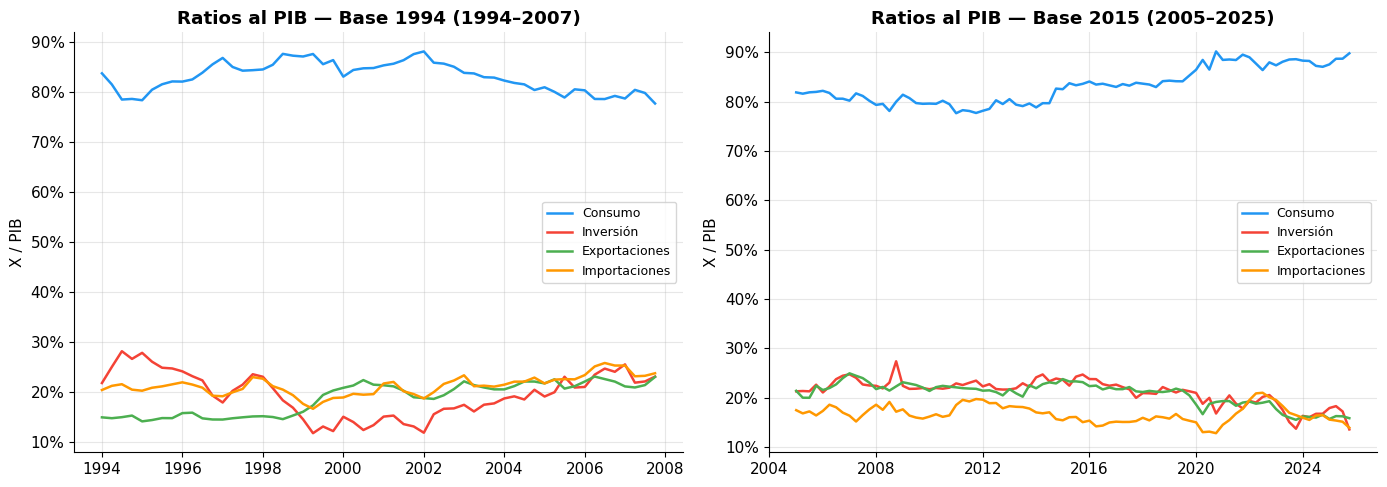


=== Tabla 1: Promedios de Largo Plazo (X/PIB) ===

              Base 1994 (1994–2007) Base 2015 (2005–2025)
Consumo                      82.99%                83.20%
Inversión                    19.55%                21.21%
Exportaciones                18.74%                20.76%
Importaciones                21.28%                16.71%


In [3]:
# ------ Relaciones de Largo Plazo ------

#X/PIB con series nominales
def calcular_ratios(df_nom):
    ratios = pd.DataFrame(index=df_nom.index)
    for var in ['consumo', 'inversion', 'exportaciones', 'importaciones']:
        ratios[var] = df_nom[var] / df_nom['pib']
    return ratios

ratios_94 = calcular_ratios(df_94_nom)
ratios_15 = calcular_ratios(df_15_nom)

#Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
etiquetas = ['Consumo', 'Inversión', 'Exportaciones', 'Importaciones']

for ax, ratios, titulo in [
    (axes[0], ratios_94, 'Base 1994 (1994–2007)'),
    (axes[1], ratios_15, 'Base 2015 (2005–2025)'),
]:
    for var, etiq, color in zip(ratios.columns, etiquetas, colores):
        ax.plot(ratios.index.to_timestamp(), ratios[var],
                label=etiq, color=color, linewidth=1.8)
    ax.set_title(f'Ratios al PIB — {titulo}', fontweight='bold')
    ax.set_ylabel('X / PIB')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/ratios_pib.png', dpi=150)
plt.show()

#Tabla (means)
tabla = pd.DataFrame({
    'Base 1994 (1994–2007)': ratios_94.mean(),
    'Base 2015 (2005–2025)': ratios_15.mean(),
})
tabla.index = etiquetas
print('\n=== Tabla 1: Promedios de Largo Plazo (X/PIB) ===\n')
print(tabla.map(lambda x: f'{x:.2%}'))

## Interpretación: Relaciones de Largo Plazo

### Consumo (~83% del PIB)
El consumo final es el componente dominante y el más estable del PIB colombiano.
Su ratio al PIB se mantiene alrededor del 83% en ambos períodos, lo que confirma
el hecho estilizado de largo plazo. Esto coincide con la característica de la
economía colombiana, marcada por un crecimiento a partir de un fuerte mercado
interno. La relativa estabilidad del consumo también refleja el comportamiento
suavizador de los hogares; por ejemplo, en la crisis de 1999, el consumo cayó
menos que el producto, amortiguando el choque.

### Inversión (~20% del PIB)
La inversión pasó de ~19.5% en el período 1994–2007 a ~21.2% en 2005–2025.
En la gráfica vemos un incremento desde 2002, y esto coincide con los gobiernos
de Uribe (2002–2010), la política de Seguridad Democrática que redujo el riesgo
país, y el auge de la inversión extranjera directa en el sector petrolero y
minero. La inversión se presume como el componente más volátil del PIB; algo que
aún estamos a la expectativa de confirmar.

### Exportaciones (~19–21% del PIB)
Las exportaciones crecieron del 18.7% al 20.8% entre períodos. Este aumento
refleja el superciclo de commodities entre 2004–2014, periodo durante el cual
los precios del petróleo y el carbón se dispararon. Colombia pasó de exportar
~$16 mil millones en 2005 a más de $60 mil millones en 2012. Sin embargo, la
caída del precio del petróleo post-2014 revirtió parte de la tendencia, lo que
explica la variabilidad en el gráfico de la Base 2015.

### Importaciones (~21% → ~17% del PIB)
La diferencia entre bases no es directamente comparable porque los precios de
referencia son distintos (base 1994 vs base 2015). Dentro de la Base 2015, las
importaciones cayeron del 17.7% (2011–2015) al 15% (2016–2020), lo que refleja
un fenómeno real: la devaluación del peso entre 2014 y 2016 (el dólar pasó de
~$1.800 a ~$3.200 COP) encareció las importaciones y redujo su volumen.
Adicionalmente, la desaceleración económica de 2015–2016 contrajo la demanda
interna.

### Anexo: Sobre la tabla
Las proporciones observadas son consistentes con el perfil de Colombia como una economía de ingreso medio orientada al mercado interno. El consumo del 83% es alto pero esperado: la clase media colombiana sostiene la demanda doméstica donde gastan la mayor parte de su ingreso en bienes y servicios locales: alimentación, vivienda, transporte, salud; los hogares suavizan su gasto incluso en crisis, en cambio paises mas ricos deciden invertir y ahorrar más. La inversión del ~20% es moderada comparada con economías asiáticas de alto crecimiento (China ~43%, Corea ~31%), lo que limita el crecimiento potencial de largo plazo (Sin inversión no hay capital y sin capital, no hay mayor productividad). Las exportaciones del ~19–21% son bajas frente a pares regionales más abiertos como Chile (~32%) o México (~38%), reflejo de que Colombia depende más del mercado interno y concentra sus exportaciones en pocos productos (petróleo, carbón, café, flores, etc). En conjunto, Colombia se parece a Brasil: grande, relativamente cerrada y consumo-intensiva.

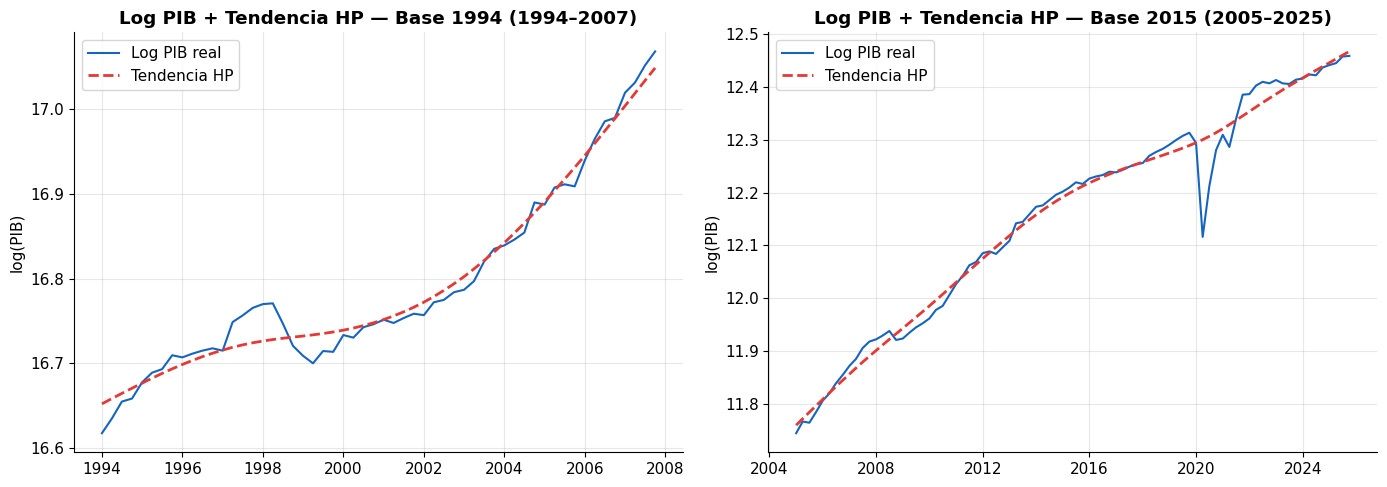

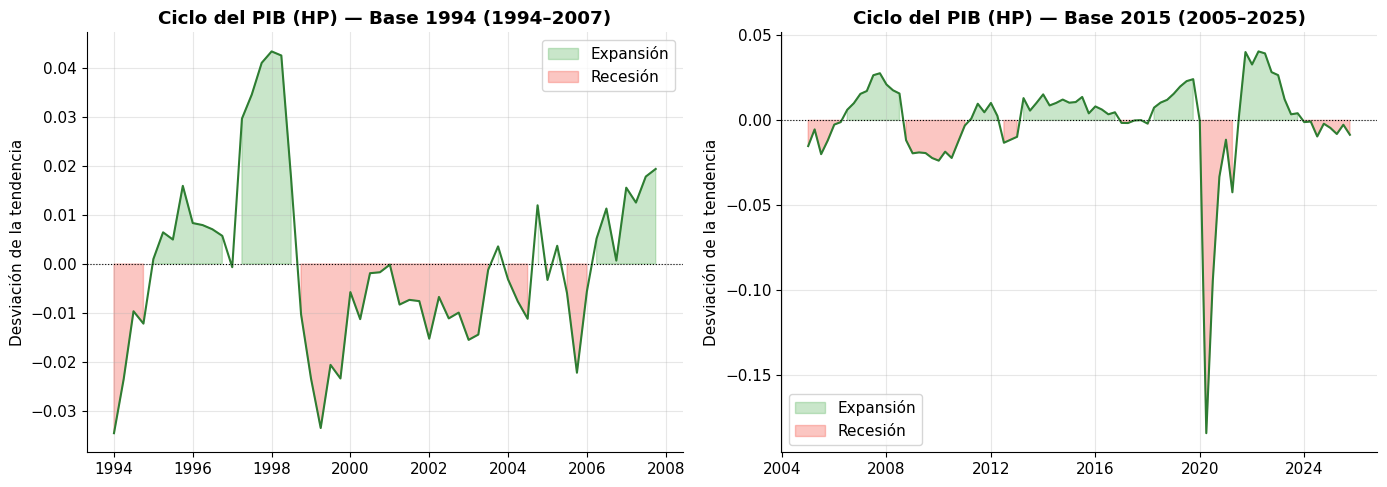

In [4]:
#------Log + Filtro HP-------

def aplicar_hp(df_real):
    """Aplica log natural y filtro HP. Devuelve logs, tendencia y ciclo."""
    logs  = np.log(df_real.dropna())
    tend  = pd.DataFrame(index=logs.index)
    ciclo = pd.DataFrame(index=logs.index)
    for var in logs.columns:
        serie = logs[var].dropna()
        c, t  = hpfilter(serie, lamb=LAMBDA_HP)
        tend[var]  = t
        ciclo[var] = c
    
    return logs, tend, ciclo

logs_94, tend_94, ciclos_94 = aplicar_hp(df_94_real)
logs_15, tend_15, ciclos_15 = aplicar_hp(df_15_real)

#1 -> log del PIB + tendencia HP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, logs, tend, titulo in [
    (axes[0], logs_94, tend_94, 'Base 1994 (1994–2007)'),
    (axes[1], logs_15, tend_15, 'Base 2015 (2005–2025)'),
]:
    fechas = logs.index.to_timestamp()
    ax.plot(fechas, logs['pib'], label='Log PIB real', color='#1565C0', linewidth=1.5)
    ax.plot(fechas, tend['pib'], label='Tendencia HP', color='#E53935', linewidth=2, linestyle='--')
    ax.set_title(f'Log PIB + Tendencia HP — {titulo}', fontweight='bold')
    ax.set_ylabel('log(PIB)')
    ax.legend()
    
plt.tight_layout()
plt.savefig('outputs/log_tendencia_hp.png', dpi=150)
plt.show()

#2 -> componente cíclico del PIB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ciclos, titulo in [
    (axes[0], ciclos_94, 'Base 1994 (1994–2007)'),
    (axes[1], ciclos_15, 'Base 2015 (2005–2025)'),
]:
    fechas = ciclos.index.to_timestamp()
    c = ciclos['pib']
    ax.plot(fechas, c, color='#2E7D32', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.fill_between(fechas, c, 0, where=(c > 0), alpha=0.3, color='#4CAF50', label='Expansión')
    ax.fill_between(fechas, c, 0, where=(c < 0), alpha=0.3, color='#F44336', label='Recesión')
    ax.set_title(f'Ciclo del PIB (HP) — {titulo}', fontweight='bold')
    ax.set_ylabel('Desviación de la tendencia')
    ax.legend()

plt.tight_layout()
plt.savefig('outputs/ciclo_pib_hp.png', dpi=150)
plt.show()

## Interpretación
### Log PIB + Tendencia HP
La tendencia HP (línea roja punteada) sigue de cerca el crecimiento del PIB
en logaritmos (línea azul), capturando la trayectoria de largo plazo sin
reaccionar a las fluctuaciones de corto plazo. Esto confirma que el filtro
funciona correctamente: suaviza la serie y deja al descubierto las desviaciones
cíclicas.

### Componente Cíclico
El ciclo extraído es claramente identificable con episodios históricos conocidos:

- **Crisis de 1999 (Base 1994):** visible como la recesión más profunda del
  período, con una desviación negativa de hasta -3%. Fue producto de la crisis
  financiera doméstica, el colapso del sistema UPAC y el contagio de la crisis
  mundiales en el `98.

- **Crisis financiera global 2008–2009 (Base 2015):** desaceleración moderada
  visible como una pequeña zona de recesión. Colombia la sorteó
  bien gracias a sus reservas internacionales y la solidez del sistema bancario.

- **COVID-19 2020 (Base 2015):** la caída más pronunciada del segundo período,
  con una desviación negativa de hasta -17%. Es el choque más grande registrado
  en la historia económica reciente de Colombia, superando incluso la crisis
  de 1999 en magnitud.

- **Recuperación 2021–2022:** expansión fuerte post-pandemia, visible como
  la zona verde más amplia del período reciente, impulsada por la reapertura
  económica y el gasto público.

El comportamiento del ciclo valida el filtro HP como herramienta: logra aislar
las fluctuaciones de corto plazo alrededor de la tendencia, que es exactamente
lo que se usa para calcular los hechos estilizados.

In [5]:
#----------Hechos Estilizados--------

def calcular_hechos(ciclos):
    """
    Calcula volatilidad, volatilidad relativa, ciclicidad y persistencia
    para cada variable en el DataFrame de ciclos.
    """
    pib = ciclos['pib'].dropna()
    sigma_y = pib.std(ddof=0)
    resultados = {}
    
    for var in ciclos.columns:
        x = ciclos[var].dropna()
        xy = pd.concat([x, pib], axis=1, join='inner')
        xy.columns = ['x', 'y']
        
        sigma_x = xy['x'].std(ddof=0) #Volatilidad
        
        vol_rel = sigma_x / sigma_y #Volatilidad relativa al PIB
        
        corr_pib = xy['x'].corr(xy['y']) #Ciclicidad
        
        persistencia = x.autocorr(lag=1) #Persistencia
        
        resultados[var] = {
            'σ (volatilidad)':              sigma_x,
            'σ/σ_PIB (vol. relativa)':      vol_rel,
            'corr(x, PIB) — ciclicidad':    corr_pib,
            'corr(x_t, x_{t-1}) — persist': persistencia,
        }
    return pd.DataFrame(resultados).T, sigma_y
he_94, sigma_y_94 = calcular_hechos(ciclos_94)
he_15, sigma_y_15 = calcular_hechos(ciclos_15)
print(f'Volatilidad PIB — Base 1994: {sigma_y_94*100:.2f}%')
print(f'Volatilidad PIB — Base 2015: {sigma_y_15*100:.2f}%')

Volatilidad PIB — Base 1994: 1.72%
Volatilidad PIB — Base 2015: 2.78%


In [6]:
#----Tabla Resumen-----

def formato_tabla(he, sigma_y, nombre):    
    def tipo_ciclo(c):
        if   c >  0.26: return f'{c:+.3f} ▲ Procíclica'
        elif c < -0.26: return f'{c:+.3f} ▼ Contracíclica'
        else:           return f'{c:+.3f} ≈ Acíclica'
    
    tabla = pd.DataFrame({
        'σ (%)':          (he['σ (volatilidad)'] * 100).map('{:.2f}'.format),
        'σ/σ_PIB':        he['σ/σ_PIB (vol. relativa)'].map('{:.3f}'.format),
        'Ciclicidad':     he['corr(x, PIB) — ciclicidad'].map(tipo_ciclo),
        'Persistencia':   he['corr(x_t, x_{t-1}) — persist'].map('{:.3f}'.format),
    })

    tabla.index = [i.capitalize() for i in tabla.index]
    print(f'\n=== HECHOS ESTILIZADOS — {nombre} ===')
    print(f'Volatilidad del PIB (σ_y): {sigma_y*100:.2f}%\n')
    print(tabla.to_string())
    return tabla
tabla_94 = formato_tabla(he_94, sigma_y_94, 'BASE 1994 (1994–2007)')
tabla_15 = formato_tabla(he_15, sigma_y_15, 'BASE 2015 (2005–2025)')


=== HECHOS ESTILIZADOS — BASE 1994 (1994–2007) ===
Volatilidad del PIB (σ_y): 1.72%

               σ (%) σ/σ_PIB           Ciclicidad Persistencia
Pib             1.72   1.000  +1.000 ▲ Procíclica        0.794
Consumo         1.80   1.045  +0.879 ▲ Procíclica        0.899
Inversion      11.05   6.425  +0.821 ▲ Procíclica        0.737
Exportaciones   3.17   1.844    +0.042 ≈ Acíclica        0.583
Importaciones   7.36   4.279  +0.839 ▲ Procíclica        0.808

=== HECHOS ESTILIZADOS — BASE 2015 (2005–2025) ===
Volatilidad del PIB (σ_y): 2.78%

              σ (%) σ/σ_PIB           Ciclicidad Persistencia
Pib            2.78   1.000  +1.000 ▲ Procíclica        0.577
Consumo        2.85   1.024  +0.952 ▲ Procíclica        0.566
Inversion      7.20   2.588  +0.722 ▲ Procíclica        0.560
Exportaciones  7.11   2.556  +0.871 ▲ Procíclica        0.601
Importaciones  6.32   2.274  +0.817 ▲ Procíclica        0.715


## Interpretación: Hechos Estilizados

### a) Volatilidad del PIB
La volatilidad del ciclo del PIB es **1.72% (Base 1994)** y **2.78% (Base 2015)**.
Para referencia, economías desarrolladas como EE.UU. tienen σ_y ≈ 1.5%, mientras
que economías emergentes suelen superar el 2%. Colombia se ubica en un rango
consistente con su condición de economía emergente, y la mayor volatilidad en
la Base 2015 se explica principalmente por el choque del COVID-19 en 2020.

### b) Volatilidades relativas
- **Consumo (σ/σ_PIB ≈ 1.0):** casi igual de volátil que el PIB. Esto confirma
  que el consumo no suaviza completamente el ciclo.
- **Inversión (σ/σ_PIB = 6.4 en B94, 2.6 en B15):** el componente más volátil
  con diferencia. Las decisiones de inversión son muy sensibles a las expectativas
  y la confianza empresarial, amplificando el ciclo.
- **Exportaciones (σ/σ_PIB = 1.8 en B94, 2.6 en B15):** alta volatilidad
  refleja la dependencia de Colombia en materias cuyos precios fluctúan
  internacionalmente.
- **Importaciones (σ/σ_PIB = 4.3 en B94, 2.3 en B15):** muy volátiles,
  respondiendo tanto al ciclo como a la tasa de cambio.

### c) Ciclicidad
- **Consumo, Inversión e Importaciones:** fuertemente procíclicas en ambos
  períodos. Cuando el PIB crece, los hogares consumen más, las empresas invierten
  más y se importan más bienes. Esto es consistente con la teoría macroeconómica
  estándar.
- **Exportaciones (Base 1994):** acíclicas (+0.042). Tiene sentido: las
  exportaciones colombianas dependen más de la demanda externa y los precios
  internacionales que del ciclo. Cuando Colombia crece, no
  necesariamente exporta más.
- **Exportaciones (Base 2015):** procíclicas (+0.871). El cambio refleja
  la mayor integración de Colombia al comercio internacional en el período
  reciente y el peso del petróleo.

### d) Persistencia
- **Consumo (0.899 en B94):** el más persistente. Los hábitos de consumo
  cambian lentamente i.e. si hoy consumes más, probablemente mañana también.
- **Inversión (0.737 en B94):** menos persistente que el consumo. Los proyectos
  de inversión pueden modificarse ante cambios en
  expectativas.
- **Exportaciones (0.583 en B94):** la menos persistente, reflejando que
  dependen de precios internacionales y que son menos predecibles.
- En la Base 2015 la persistencia es menor en general, posiblemente porque
  el COVID-19 generó un choque grande.